In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range

import matplotlib.patches as ps
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
from matplotlib.colors import LogNorm
from visualize_hops import visualize_current, current_snapshot
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import LogFormatterSciNotation
from mpl_toolkits.axes_grid1 import make_axes_locatable

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print('Libraries loaded')

data_type = 'uni_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model = model.to(device)

cuda
Libraries loaded


In [2]:
input_index_0 = 2
input_index_1 = 4

num_voltages = 7

e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

control_indices = [c_index for c_index in range(num_voltages) if c_index not in (input_index_0,input_index_1)]
c_v_min = -1.5
c_v_max = 1.5
model = model.to(device)
with torch.no_grad():
    x = torch.zeros(4096, num_voltages, device=device)
    x.uniform_(c_v_min, c_v_max)     # or whatever voltage range you use
    y = model(x).squeeze()
    S_std = y.std().item()
    S_med = y.abs().median().item()
print("std:", S_std, "median|y|:", S_med)

#print(control_indices)
# XOR
on_volt = 0.5
gate_inputs = [
    [0.0, 0.0],
    [0.0, on_volt],
    [on_volt, 0.0],
    [on_volt, on_volt]
]

gate = 'XOR'

if gate == 'XOR':
    truth_outputs = [
        0.,
        1.,
        1.,
        0.
    ]

elif gate == 'AND':
    truth_outputs = [
        0.,
        0.,
        0.,
        1.
    ]

elif gate == 'OR':
    truth_outputs = [
        0.,
        1.,
        1.,
        1.
    ]

elif gate == 'NOR':
    truth_outputs = [
        1.,
        0.,
        0.,
        0.
    ]

elif gate == 'NAND':
    truth_outputs = [
        1.,
        1.,
        1.,
        0.
    ]

std: 27.43882179260254 median|y|: 23.18789291381836


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def current_distribution_shared(
    ax,
    add_cbar,                # kept for API compatibility (not used here)
    device_data,
    alpha_cutoff,            # cutoff in nA
    cmap,                    # energy/electrode colormap name
    curr_norm=None,          # shared current norm (in log10 space), or None to auto-create
    E_norm=None,             # shared energy norm, or None to auto-create
    curr_cmap_name="Greys",  # current colormap name
    curr_vminmax=None,       # optional (vmin, vmax) for current in *linear* nA, if you want to force it
):
    """
    Draw device nodes/electrodes and directed triangle "currents".
    Returns:
        ax, sm_E, sm_I, curr_norm_used, E_norm_used

    Notes:
      - Current color is mapped in log10 space via curr_norm.
      - If you want a *shared* current colorbar across multiple panels, compute curr_norm once
        and pass it into every call.
      - Same for E_norm (energies/electrode colors).
    """

    # -------------------------
    # Load data
    # -------------------------
    e_0 = 1.60217663e-19
    kbT = 77.0 * 1.380649e-23

    events = device_data["event_matrix"]
    simulation_time = device_data["sim_time"]
    acc_xy = device_data["acc_xy"]
    ele_xy = device_data["ele_xy"]
    energies = device_data["energies"] * kbT / e_0

    n_A = acc_xy.shape[0]
    n_E = ele_xy.shape[0]

    # nA scaling + (your) seconds scaling
    current_scaling_factor = 1e9 * 1e12

    net_events = (events - events.T)
    abs_current = np.abs(net_events) / simulation_time * e_0 * current_scaling_factor  # nA

    positive = abs_current[abs_current > 0]
    if positive.size == 0:
        # nothing to draw in terms of current; still draw nodes/electrodes
        # build some safe defaults for norms if needed
        if curr_norm is None:
            curr_norm = plt.Normalize(vmin=0.0, vmax=1.0, clip=True)
        if E_norm is None:
            E_norm = plt.Normalize(vmin=float(np.min(energies)), vmax=float(np.max(energies)))
    else:
        # -------------------------
        # Current scaling (log space)
        # -------------------------
        if curr_vminmax is not None:
            vmin_lin, vmax_lin = curr_vminmax
            vmin_lin = max(vmin_lin, positive.min())
            vmax_lin = max(vmax_lin, vmin_lin * 1.0001)
        else:
            vmin_lin = np.percentile(positive, 0.1)
            vmax_lin = np.percentile(positive, 99.0)
            vmin_lin = max(vmin_lin, positive.min())
            vmax_lin = max(vmax_lin, vmin_lin * 1.0001)

        # Create a default norm if caller didn't supply one:
        # IMPORTANT: curr_norm maps log10(I) values (not I itself)
        if curr_norm is None:
            curr_norm = plt.Normalize(
                vmin=np.log10(vmin_lin),
                vmax=np.log10(vmax_lin),
                clip=True
            )

        # -------------------------
        # Energy/voltage colormap
        # -------------------------
        if E_norm is None:
            E_norm = plt.Normalize(vmin=float(energies.min()), vmax=float(energies.max()))

    # helper: safe log10
    def logI(I, vmin_lin):
        return np.log10(max(I, vmin_lin))

    # alpha mapping in log space
    def alpha_from_current(I, vmin_lin, vmax_lin, a_min=0.05, a_max=0.95):
        t = (np.log10(I) - np.log10(vmin_lin)) / (np.log10(vmax_lin) - np.log10(vmin_lin))
        t = np.clip(t, 0.0, 1.0)
        return a_min + t * (a_max - a_min)

    # If there were no positive currents, define some harmless defaults for alpha mapping
    if positive.size == 0:
        vmin_lin = 1.0
        vmax_lin = 10.0

    # colormaps
    curr_cmap = plt.get_cmap(curr_cmap_name)
    E_cmap = plt.get_cmap(cmap)
    colors = E_cmap(E_norm(energies))

    # -------------------------
    # Plot geometry
    # -------------------------
    ax.set_aspect("equal", adjustable="box")

    # device boundary
    R_norm = np.sqrt(150.0*150.0*np.pi / n_A)
    radius = 150 / R_norm#float(np.max(np.linalg.norm(acc_xy, axis=1)))
    ax.add_patch(
        ps.Circle(
            xy=(0.0, 0.0),
            radius=radius + 0.15,
            fill=None,
            edgecolor="k",
            zorder=4,
            lw=4,
        )
    )

    # electrodes
    arcs = []
    th = np.linspace(0.0, 315, n_E)
    th_width = 12.5

    for i in range(n_E):
        arcs.append(
            ps.Wedge(
                center=(0, 0),
                r=radius + 0.45,
                fc=colors[i + n_A],
                ec="k",
                theta1=th[i] - th_width,
                theta2=th[i] + th_width,
                width=0.4,
                zorder=5,
            )
        )
    for arc in arcs:
        ax.add_patch(arc)

    # acceptor nodes
    node_radius = 0.13
    base_width = 2.0 * node_radius
    for i, pt in enumerate(acc_xy):
        ax.add_patch(
            ps.Circle(
                xy=(pt[0], pt[1]),
                radius=node_radius,
                zorder=4,
                color=colors[i],
            )
        )

    # -------------------------
    # Plot currents between acceptors
    # -------------------------
    for i in range(n_A):
        for j in range(n_A):
            I = abs_current[i, j]  # nA
            if I <= 0 or I < alpha_cutoff:
                continue

            # direction
            if net_events[i, j] > 0:
                src, dest = acc_xy[i], acc_xy[j]
            elif net_events[i, j] < 0:
                src, dest = acc_xy[j], acc_xy[i]
            else:
                continue

            tri = triangle_from_src_to_dst(src, dest, base_width)
            if tri is None:
                continue

            a = alpha_from_current(I, vmin_lin, vmax_lin)
            fc = curr_cmap(curr_norm(logI(I, vmin_lin)))

            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,
                    edgecolor="none",
                    alpha=a,
                    zorder=3,
                )
            )

    # -------------------------
    # Plot currents between acceptors and electrodes
    # -------------------------
    elec_idx = np.arange(n_A, n_A + n_E)  # indices in full matrix

    for i in range(n_A):
        for j in elec_idx:
            I = abs_current[i, j]  # nA
            if I <= 0 or I < alpha_cutoff:
                continue

            k = j - n_A  # electrode index into ele_xy

            if net_events[i, j] > 0:
                src, dest = acc_xy[i], ele_xy[k]
            elif net_events[i, j] < 0:
                src, dest = ele_xy[k], acc_xy[i]
            else:
                continue

            tri = triangle_from_src_to_dst(src, dest, base_width)
            if tri is None:
                continue

            a = alpha_from_current(I, vmin_lin, vmax_lin)
            fc = curr_cmap(curr_norm(logI(I, vmin_lin)))

            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,
                    edgecolor="none",
                    alpha=a,
                    zorder=3,
                )
            )

    # -------------------------
    # Final axis styling
    # -------------------------
    ax.set_xlim(-radius - 0.5, radius + 0.5)
    ax.set_ylim(-radius - 0.5, radius + 0.5)
    ax.axis("off")

    # mappables for *figure-level* shared colorbars
    sm_I = ScalarMappable(norm=curr_norm, cmap=curr_cmap)
    sm_I.set_array([])

    sm_E = ScalarMappable(norm=E_norm, cmap=E_cmap)
    sm_E.set_array([])

    return ax, sm_E, sm_I, curr_norm, E_norm

def triangle_from_src_to_dst(src, dst, base_width):
    """
    Return the 3 vertices of an isosceles triangle whose base is centered at src
    (length = base_width) and whose tip is at dst.
    """
    v = dst - src
    L = np.linalg.norm(v)
    if L == 0:
        return None  # same point, nothing to draw
    u = v / L                        # direction from src to dst
    n = np.array([-u[1], u[0]])      # unit normal (perpendicular)
    half = 0.5 * base_width

    p_left  = src + half * n
    p_right = src - half * n
    tip     = dst
    return np.vstack([p_left, p_right, tip])

def current_distribution(ax, add_cbar, device_data, alpha_cutoff, cmap, curr_norm):

    def logI(I):
        return np.log10(max(I, vmin))
    
    """ Load data"""
    e_0 = 1.60217663e-19
    kbT = 77.0*1.380649e-23
    events = device_data['event_matrix']
    #print(events.shape)
    simulation_time = device_data['sim_time']
    acc_xy = device_data['acc_xy']
    don_xy = device_data['don_xy']
    ele_xy = device_data['ele_xy']
    energies = device_data['energies'] * kbT / e_0

    n_A = acc_xy.shape[0]
    n_E = ele_xy.shape[0]

    current_scaling_factor = 1e9*1e12 # nanon ampere and time to secondes 

    net_events = (events - events.T)
    dir_rows, dir_cols = np.where(net_events > 0)
    #lower_half_currents = np.abs(np.tril(net_events, k=-1))
    abs_current = np.abs(net_events) / simulation_time * e_0 * current_scaling_factor

    """positive = abs_current[abs_current > 0]

    vmin = positive.min()
    vmax = positive.max()
    curr_norm = LogNorm(vmin=vmin, vmax=vmax)"""
    positive = abs_current[abs_current > 0]
    vmin = np.percentile(positive, 0.1)   # try 1–5
    vmax = np.percentile(positive, 99)  # try 95–99
    vmin = max(vmin, positive.min())
    vmax = max(vmax, vmin * 1.0001)

    if curr_norm is None:
        #curr_norm = LogNorm(vmin=vmin, vmax=vmax, clip=True)
        curr_norm = plt.Normalize(vmin=np.log10(vmin), vmax=np.log10(vmax), clip=True)
    else:
        curr_norm = curr_norm
    curr_cmap = plt.get_cmap('Greys')
    
    def alpha_from_current(I, vmin, vmax, a_min=0.05, a_max=0.95):
        # map current to [0,1] in log space, then to [a_min, a_max]
        t = (np.log10(I) - np.log10(vmin)) / (np.log10(vmax) - np.log10(vmin))
        t = np.clip(t, 0.0, 1.0)
        return a_min + t * (a_max - a_min)

    min_current = abs_current.min()
    max_current = abs_current.max()
    #print(min_current)
    #print(max_current)
    #print(events.sum())

    abs_current_normalized = abs_current #/ max_current
    #abs_current_normalized = log_scaling(abs_current, None)

    acc_face_clr = (0, 0.6, 0, 1)

    """ Energies to color """
    cmap = plt.get_cmap(cmap)
    norm = plt.Normalize(vmin=energies.min(), vmax=energies.max())
    colors = cmap(norm(energies))

    ax.set_aspect('equal', adjustable='box')

    """ Device boundary """
    radius = float(np.max(np.linalg.norm(acc_xy, axis=1)))
    device_boundary = ps.Circle(
        xy=(0.0, 0.0),
        radius=radius+0.15,
        fill=None,
        edgecolor='k',
        zorder=4,
        lw=4
    )
    ax.add_patch(device_boundary)

    """ Electrodes """
    arcs = []
    th = np.linspace(0.0, 315, n_E)
    th_width = 12.5
    for i in range(n_E):
        """arcs.append(
            ps.Arc(
                xy=(0.0, 0.0),
                width=2*radius + 0.40,
                height=2*radius + 0.40,
                linewidth=8,
                color=colors[i + n_A],
                theta1=th[i]-th_width,
                theta2=th[i]+th_width,
                zorder=5
            )
        )"""
        arcs.append(
            ps.Wedge(
                center=(0, 0),
                r=radius + .45,
                fc=colors[i+n_A],
                ec='k',
                theta1=th[i]-th_width,
                theta2=th[i]+th_width,
                width = 0.4,
                zorder=5,
            )
        )
        
    for i, arc in enumerate(arcs):
        ax.add_patch(arc)
        #ax.text(x=(radius + 0.4)*np.cos(th[i]), y=(radius + 0.4)*np.sin(th[i]), s=rf'$V_{i}$')
        
    """ Acceptor and donors """
    node_radius = 0.13
    base_width = 2.0 * node_radius
    for i, pt in enumerate(acc_xy):
        ax.add_patch(
            ps.Circle(
                xy=(pt[0], pt[1]),
                radius=node_radius,
                zorder=4,
                color=colors[i]
            )
        )

    """ Plot currents between acceptors """
    for i in range(n_A):
        for j in range(n_A):
            I = abs_current[i, j]  # current in nA
            if I <= 0:
                continue
            
            # IMPORTANT: alpha_cutoff is now interpreted in nA
            if I < alpha_cutoff:
                continue
            
            a = alpha_from_current(I, vmin, vmax)
            fc = curr_cmap(curr_norm(logI(I)))#curr_cmap(curr_norm(I))  # color encodes current too (matches colorbar)
            
            if net_events[i, j] > 0:
                src = acc_xy[i]
                dest = acc_xy[j]
                tri = triangle_from_src_to_dst(src, dest, base_width)
            elif net_events[i, j] < 0:
                src = acc_xy[j]
                dest = acc_xy[i]
                tri = triangle_from_src_to_dst(src, dest, base_width)
            else:
                continue
            
            if tri is None:
                continue
            
            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,      # was 'black'
                    edgecolor='none',
                    alpha=a,           # was a_val (way too large / not in [0,1])
                    zorder=3
                )
            )
            """a_val = abs_current_normalized[i, j]
            if a_val > alpha_cutoff:
                if net_events[i, j] > 0:
                    src = acc_xy[i]
                    dest = acc_xy[j]
                    tri = triangle_from_src_to_dst(src, dest, base_width)
                    if tri is None:
                        continue
                    ax.add_patch(
                        ps.Polygon(
                            tri,
                            closed=True,
                            facecolor='black',
                            edgecolor='none',
                            alpha=a_val,#alpha=np.sqrt(a_val),
                            zorder=3
                        )
                    )
                elif net_events[i, j] < 0:
                    src = acc_xy[j]
                    dest = acc_xy[i]
                    tri = triangle_from_src_to_dst(src, dest, node_radius)
                    if tri is None:
                        continue
                    ax.add_patch(
                        ps.Polygon(
                            tri,
                            closed=True,
                            facecolor='black',
                            edgecolor='none',
                            alpha=a_val,#alpha=np.sqrt(a_val),
                            zorder=3
                        )
                    )"""

    # indices in the full 208x208 matrix
    elec_idx = np.arange(n_A, n_A + n_E)   # last n_E indices
    
    # Plot currents between acceptors and electrodes
    for i in range(n_A):                  # acceptor index
        for j in elec_idx:                # electrode indices in matrix
            I = abs_current[i, j]         # nA
            if I <= 0 or I < alpha_cutoff:
                continue
    
            a  = alpha_from_current(I, vmin, vmax)
            fc = curr_cmap(curr_norm(logI(I)))#curr_cmap(curr_norm(I))
    
            k = j - n_A                   # electrode number 0..n_E-1 to index ele_xy
    
            # Direction from net_events decides arrow direction
            if net_events[i, j] > 0:
                src  = acc_xy[i]
                dest = ele_xy[k]
            elif net_events[i, j] < 0:
                src  = ele_xy[k]
                dest = acc_xy[i]
            else:
                continue
    
            tri = triangle_from_src_to_dst(src, dest, base_width)
            if tri is None:
                continue
    
            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,
                    edgecolor='none',
                    alpha=a,
                    zorder=3
                )
            )
    
    cbar_E = None
    cbar_I = None

    ax.set_xlim(-radius - 0.5, radius + 0.5)
    ax.set_ylim(-radius - 0.5, radius + 0.5)
    ax.axis('off')
    
    # Create mappables for colorbars (but do NOT draw colorbars here)
    sm_I = ScalarMappable(norm=curr_norm, cmap=curr_cmap)
    sm_I.set_array([])
    
    sm_E = ScalarMappable(norm=norm, cmap=cmap)
    sm_E.set_array([])
    
    return ax, sm_E, sm_I

def plot_gate_from_currents(gate_inputs, currents, currents_sem=None, sim_currents=None, sim_sem=None):
    y = np.asarray(currents, dtype=float).reshape(-1)
    if len(y) != len(gate_inputs):
        raise ValueError("`currents` length must match gate_inputs length.")

    if currents_sem is not None:
        sem = np.asarray(currents_sem, dtype=float).reshape(-1)
        if len(sem) != len(gate_inputs):
            raise ValueError("`currents_sem` length must match gate_inputs length.")
    else:
        sem = None

    if sim_currents is not None:
        y_sim = np.asarray(sim_currents, dtype=float).reshape(-1)
        if len(y_sim) != len(gate_inputs):
            raise ValueError("`sim_currents` length must match gate_inputs length.")
    else:
        y_sim = None

    if sim_sem is not None:
        sim_sem = 1.96*np.asarray(sim_sem, dtype=float).reshape(-1)
        if len(sim_sem) != len(gate_inputs):
            raise ValueError("`sim_sem` length must match gate_inputs length.")
    else:
        sim_sem = None

    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]

    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)

    labels = ["$V_1$", "$V_2$", "$I_{\\mathrm{out}} \\quad [nA]$"]
    t = np.arange(len(gate_inputs) + 1)  # 0..4

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # ---- output (mean step) ----
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=1, label="ground truth")

    # ---- shaded SEM band (mean ± sem) ----
    if sem is not None:
        lo = np.r_[y - sem, (y - sem)[-1]]
        hi = np.r_[y + sem, (y + sem)[-1]]
        axes[2].fill_between(t, lo, hi, step="post", alpha=0.25)

    # optional overlay: simulated
    if y_sim is not None:
        y_sim_out = np.r_[y_sim, y_sim[-1]]
        axes[2].step(t, y_sim_out, where="post", lw=2, ls="--", label="simulated")

        if sim_sem is not None:
            lo_s = np.r_[y_sim - sim_sem, (y_sim - sim_sem)[-1]]
            hi_s = np.r_[y_sim + sim_sem, (y_sim + sim_sem)[-1]]
            axes[2].fill_between(t, lo_s, hi_s, step="post", alpha=0.15)

        axes[2].legend(frameon=False, loc="best")

    style_axis(axes[2], labels[2])

    # ---- inputs ----
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])

    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])

    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_1, V_2 \\quad [V]$")

    return axes

def plot_gate(model, theta, control_indices, gate_inputs):

    input_tensor = torch.zeros(len(gate_inputs), num_voltages)
    control_voltages = torch.from_numpy(theta).float().expand(len(gate_inputs), -1)
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = control_voltages[:, j]
    
    for k in range(len(gate_inputs)):
        input_tensor[k, input_index_0] = gate_inputs[k][0]
        input_tensor[k, input_index_1] = gate_inputs[k][1]
    input_tensor = input_tensor.to(device)

    model.eval()
    with torch.no_grad():
        y = (model(input_tensor).detach().cpu().squeeze().numpy()).tolist()
    #print(y)
    in_0 = [gate_inputs[0][0], gate_inputs[1][0], gate_inputs[2][0], gate_inputs[3][0]]
    in_1 = [gate_inputs[0][1], gate_inputs[1][1], gate_inputs[2][1], gate_inputs[3][1]]
    
    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)

    labels = ["$V_1$", "$V_2$", "$I_{\mathrm{out}} \quad [nA]$"]
    
    # time axis: 4 states -> 5 edges
    t = np.arange(len(in_0) + 1)
    
    # helper: nice common style
    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)#, ha="right", va="center")
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        # remove top/right spines
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    
    # output
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=2)
    style_axis(axes[2], labels[2])
    
    # input 0
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])
    
    # input 1
    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])
    
    # x-ticks at the middle of each interval, labeled by input combination
    centers = np.arange(len(y)) + 0.5
    state_labels = ["00", "01", "10", "11"]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_1, V_2 \quad [V]$")
    
    # small margins so steps aren't glued to edges
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        margin = 0.1 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - margin, ymax + margin)
        #ax.set_box_aspect(1)
    
    return axes

import matplotlib.pyplot as plt

def make_gate_axes(figsize=(6,4), left=0.15, right=0.95, bottom=0.15, top=0.95, hspace=0.15):
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=3, ncols=1,
        left=left, right=right, bottom=bottom, top=top,
        hspace=hspace
    )
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    ax2 = fig.add_subplot(gs[2, 0], sharex=ax0)
    return fig, (ax0, ax1, ax2)


def plot_gate_into_axes(model, theta, control_indices, gate_inputs, axes):
    ax0, ax1, ax2 = axes

    # --- compute y as before ---
    input_tensor = torch.zeros(len(gate_inputs), num_voltages)
    control_voltages = torch.from_numpy(theta).float().expand(len(gate_inputs), -1)
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = control_voltages[:, j]
    for k in range(len(gate_inputs)):
        input_tensor[k, input_index_0] = gate_inputs[k][0]
        input_tensor[k, input_index_1] = gate_inputs[k][1]
    input_tensor = input_tensor.to(device)

    model.eval()
    with torch.no_grad():
        y = model(input_tensor).detach().cpu().squeeze().numpy()

    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]

    t = np.arange(len(gate_inputs) + 1)

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # output
    ax2.step(t, np.r_[y, y[-1]], where="post", lw=2)
    style_axis(ax2, r"$I_{\mathrm{out}} \quad [nA]$")

    # inputs
    ax0.step(t, np.r_[in_0, in_0[-1]], where="post", lw=2, c="r")
    style_axis(ax0, r"$V_1$")
    ax1.step(t, np.r_[in_1, in_1[-1]], where="post", lw=2, c="g")
    style_axis(ax1, r"$V_2$")

    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    ax2.set_xticks(centers)
    ax2.set_xticklabels(state_labels)
    ax2.set_xlabel(r"Input $V_1, V_2 \quad [V]$")

    return y  # return y so we can match ylims if desired


def plot_currents_into_axes(gate_inputs, currents, currents_sem=None, sim_currents=None, sim_sem=None, axes=None):
    ax0, ax1, ax2 = axes

    y = np.asarray(currents, float).reshape(-1)
    sem = None if currents_sem is None else np.asarray(currents_sem, float).reshape(-1)

    y_sim = None if sim_currents is None else np.asarray(sim_currents, float).reshape(-1)
    sim_sem_ = None if sim_sem is None else 1.96*np.asarray(sim_sem, float).reshape(-1)

    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]
    t = np.arange(len(gate_inputs) + 1)

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    ax2.step(t, np.r_[y, y[-1]], where="post", lw=1, label="ground truth")

    if sem is not None:
        sem = 1.96*sem
        lo = np.r_[y - sem, (y - sem)[-1]]
        hi = np.r_[y + sem, (y + sem)[-1]]
        ax2.fill_between(t, lo, hi, step="post", alpha=0.25)

    if y_sim is not None:
        ax2.step(t, np.r_[y_sim, y_sim[-1]], where="post", lw=2, ls="--", label="simulated")
        if sim_sem_ is not None:
            lo_s = np.r_[y_sim - sim_sem_, (y_sim - sim_sem_)[-1]]
            hi_s = np.r_[y_sim + sim_sem_, (y_sim + sim_sem_)[-1]]
            ax2.fill_between(t, lo_s, hi_s, step="post", alpha=0.15)
        ax2.legend(frameon=False, loc="best")

    style_axis(ax2, r"$I_{\mathrm{out}} \quad [nA]$")

    ax0.step(t, np.r_[in_0, in_0[-1]], where="post", lw=2, c="r")
    style_axis(ax0, r"$V_1$")
    ax1.step(t, np.r_[in_1, in_1[-1]], where="post", lw=2, c="g")
    style_axis(ax1, r"$V_2$")

    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    ax2.set_xticks(centers)
    ax2.set_xticklabels(state_labels)
    ax2.set_xlabel(r"Input $V_1, V_2 \quad [V]$")

    return y


print('DONE')

DONE


[ 0.         -0.2681939  -0.83940589  0.          0.42605829  0.
  0.1440258   0.04129112]
[-0.2681939  -0.83940589  0.42605829  0.1440258   0.04129112]
True Is: [array([-16.85769633]), array([-16.4777888]), array([-14.66042702]), array([-19.08947182])]
Is sem: [array([0.14324856]), array([0.13382359]), array([0.13865855]), array([0.15095886])]


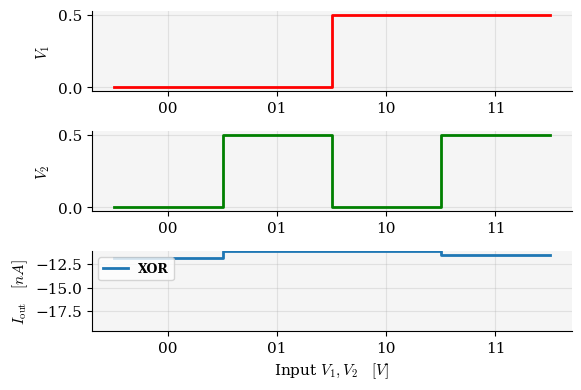

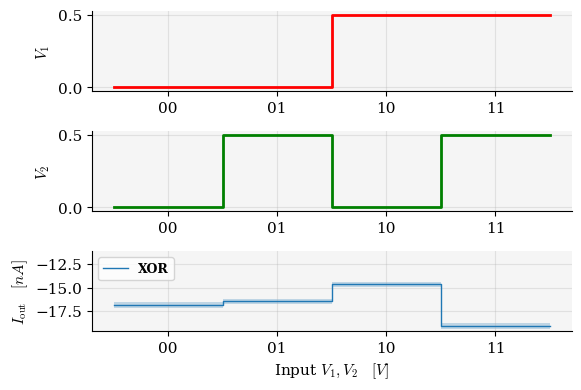

In [4]:
gate = 'XOR'

C = 1.602e-19
scale = 1e21

data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_0.0_0.0_new_1.npz')
input_data = data['inputs']
print(input_data)
best_theta = np.delete(input_data, [0, input_index_0+1, input_index_1+1])
print(best_theta)

I_00 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_0.0_0.0_new_1.npz')['current'] * scale
I_01 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_0.0_{on_volt}_new_1.npz')['current'] * scale
I_10 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_{on_volt}_0.0_new_1.npz')['current'] * scale
I_11 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_{on_volt}_{on_volt}_new_1.npz')['current'] * scale

I_00_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_0.0_0.0_new_1.npz')['sem'] * scale
I_01_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_0.0_{on_volt}_new_1.npz')['sem'] * scale
I_10_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_{on_volt}_0.0_new_1.npz')['sem'] * scale
I_11_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_{on_volt}_{on_volt}_new_1.npz')['sem'] * scale

true_Is = [I_00, I_01, I_10, I_11]
Is_sem = [I_00_sem, I_01_sem, I_10_sem, I_11_sem]
print('True Is:', true_Is)
print('Is sem:', Is_sem)

fig_sm, axes_sm = make_gate_axes(figsize=(6,4), hspace=0.5)
y_sm = plot_gate_into_axes(model, best_theta, control_indices, gate_inputs, axes_sm)

fig_kmc, axes_kmc = make_gate_axes(figsize=(6,4), hspace=0.5)
y_kmc = plot_currents_into_axes(gate_inputs, true_Is, Is_sem, axes=axes_kmc)

# (optional but helps overlay): force identical y-limits for each corresponding axis
for a_sm, a_kmc in zip(axes_sm, axes_kmc):
    lo = min(a_sm.get_ylim()[0], a_kmc.get_ylim()[0])
    hi = max(a_sm.get_ylim()[1], a_kmc.get_ylim()[1])
    a_sm.set_ylim(lo, hi)
    a_kmc.set_ylim(lo, hi)

fig_sm.canvas.draw()
fig_kmc.canvas.draw()

axes_sm[2].legend(labels=[f'{gate}'], loc='upper left', prop={'weight': 'bold', 'size': 9})
axes_kmc[2].legend(labels=[f'{gate}'], loc='upper left', prop={'weight': 'bold', 'size': 9})

#axes_sm[0].set_title(f'SM {gate}', fontweight='bold')
#axes_kmc[0].set_title(f'kMC simulation {gate}', fontweight='bold')

# Save WITHOUT bbox_inches="tight" to preserve identical canvases:
#fig_sm.savefig(f"{data_type}_{gate}_sm_new_1.pdf")
#fig_kmc.savefig(f"{data_type}_{gate}_kmc_new_1.pdf")

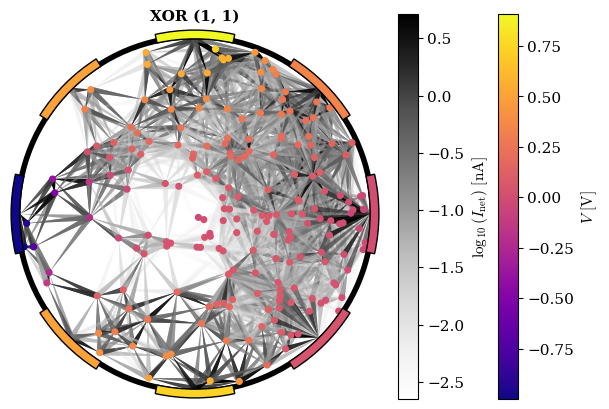

In [5]:
import matplotlib.ticker as mticker
data_type = 'grad_towards_1e7'
gate = 'XOR'

volt_1 = .5
volt_2 = .5
device_data_0 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha=1.0/{data_type}_gate={gate}_{volt_1}_{volt_2}_new_1.npz')

fig, ax = plt.subplots(figsize=(5, 5))

a_0, sm_E, sm_I = current_distribution(ax, True, device_data_0, 0.0, cmap='plasma', curr_norm=None)

pos = ax.get_position()  # Bbox of the right plot in figure coords
#print(pos)

w = 0.04
pad = 0.02
#cbar = fig.colorbar(sm_I, cax=cax_I)

# current colorbar (first)
cax_I = fig.add_axes([pos.x1+pad, pos.y0, w, pos.height])

cbar = fig.colorbar(sm_I, cax=cax_I)

# log axis
#cbar.ax.set_yscale('log')

# ticks at 1,2,5 × 10^n (as floats, not 10^n labels)
cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
cbar.ax.yaxis.set_minor_locator(mticker.NullLocator())

# format as plain numbers (no scientific notation)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:g}"))

cbar.set_label(r"$\log_{10}(I_{\mathrm{net}}) \, \, [\mathrm{nA}]$")
cbar.update_ticks()

# energy colorbar (second, further right)
cax_E = fig.add_axes([pos.x1+0.2+pad, pos.y0, w, pos.height])
cbar_E = fig.colorbar(sm_E, cax=cax_E)
cbar_E.set_label(r"$V \, \, [\mathrm{V}]$")
#cbar_E.set_ticks([-1.5, 0.0, 1.5])

a_0.set_box_aspect(1)
a_0.set_title(f'{gate} ({int(volt_1 > 0.0)}, {int(volt_2 > 0.0)})', fontweight='bold')
fig.subplots_adjust(top=0.85)
#fig.savefig(f'{data_type}_{gate}_{int(volt_1 > 0.0)}_{int(volt_2 > 0.0)}_current_distribution_new_1.png', bbox_inches='tight')
plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps
from matplotlib.cm import ScalarMappable

def current_distribution_shared_labeled_new(
    ax,
    add_cbar,                # kept for API compatibility (not used here)
    device_data,
    alpha_cutoff,            # cutoff in nA, now applied to TOTAL traffic (I_ij + I_ji)
    cmap,                    # energy/electrode colormap name
    curr_norm=None,          # shared norm for TOTAL traffic (in transformed space), or None to auto-create
    E_norm=None,             # shared energy norm, or None to auto-create
    curr_cmap_name="Greys",  # kept for API compatibility (not used; we use red<->green like readSwapps)
    curr_vminmax=None,       # optional (vmin, vmax) for TOTAL traffic in *linear* nA, if you want to force it

    # --- NEW/CHANGED: match readSwapps semantics ---
    mode="log",              # "raw", "sqrt", "log"  (how to compress TOTAL traffic before alpha/norm)
    a_min=0.0,               # minimum alpha (readSwapps effectively uses 0..1); set >0 if you want always-visible edges

    # --- electrode labeling ---
    electrode_label_map=None,        # dict: {electrode_index: "label", ...}
    electrode_label_r=None,          # radius at which labels are placed; None -> auto
    electrode_label_kwargs=None      # dict of kwargs passed to ax.text
):
    """
    UPDATED to mimic readSwapps "current distribution" look:
      - Direction: decided by comparing forward vs backward directed rates.
      - Alpha: proportional to TOTAL traffic on the undirected edge (I_ij + I_ji), after mode transform.
      - Color: proportional to DIRECTIONALITY BIAS |r - 0.5| where r = I_ij / (I_ij + I_ji),
               using a red<->green interpolation like readSwapps' colorMaker().

    Triangles still encode direction geometrically (tip points along net direction).
    Electrode / node colors still come from energies via `cmap`.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as ps
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import LinearSegmentedColormap

    # -------------------------
    # Load data
    # -------------------------
    e_0 = 1.60217663e-19
    kbT = 77.0 * 1.380649e-23

    events = device_data["event_matrix"]     # directed counts (or weights) between all sites
    simulation_time = device_data["sim_time"]
    acc_xy = device_data["acc_xy"]
    ele_xy = device_data["ele_xy"]
    energies = device_data["energies"] * kbT / e_0

    n_A = acc_xy.shape[0]
    n_E = ele_xy.shape[0]

    # same scaling you had (kept)
    current_scaling_factor = 1e9 * 1e12  # -> nA (with your extra 1e12 factor)

    # -------------------------
    # Build directed "currents" from directed events (NOT net)
    # -------------------------
    # Directed current-like quantity (nA)
    # (If events are already rates, you might not want /simulation_time. Here we assume counts, like before.)
    I_dir = (events / simulation_time) * e_0 * current_scaling_factor  # nA, directed

    # Total (undirected) traffic strength between i and j (nA)
    S_lin = I_dir + I_dir.T  # S_ij = I_ij + I_ji

    # We'll use this to determine triangle direction:
    # net_dir_ij > 0 means i->j dominates
    net_dir = I_dir - I_dir.T

    # -------------------------
    # Decide global ranges for total traffic normalization (like readSwapps absBins)
    # -------------------------
    positive_S = S_lin[S_lin > 0]
    if positive_S.size == 0:
        # still draw nodes/electrodes; no triangles
        if E_norm is None:
            E_norm = plt.Normalize(vmin=float(energies.min()), vmax=float(energies.max()))
        if curr_norm is None:
            curr_norm = plt.Normalize(vmin=0.0, vmax=1.0, clip=True)
        # create dummy mappables
        sm_I = ScalarMappable(norm=curr_norm, cmap=plt.get_cmap("Greys"))
        sm_I.set_array([])
        sm_E = ScalarMappable(norm=E_norm, cmap=plt.get_cmap(cmap))
        sm_E.set_array([])
        return ax, sm_E, sm_I, curr_norm, E_norm

    # optional user-forced linear vmin/vmax on total traffic
    if curr_vminmax is not None:
        vmin_lin, vmax_lin = curr_vminmax
        vmin_lin = max(vmin_lin, positive_S.min())
        vmax_lin = max(vmax_lin, vmin_lin * 1.0001)
    else:
        # mimic your percentile logic (but applied to total traffic)
        vmin_lin = np.percentile(positive_S, 0.1)
        vmax_lin = np.percentile(positive_S, 99.0)
        vmin_lin = max(vmin_lin, positive_S.min())
        vmax_lin = max(vmax_lin, vmin_lin * 1.0001)

    # transform total traffic like readSwapps: raw/sqrt/log
    def transform_strength(x):
        if mode == "raw":
            return x
        if mode == "sqrt":
            return np.sqrt(np.maximum(x, 0.0))
        if mode == "log":
            # safer than log(x) with zeros; readSwapps used log after replacing zeros with 1
            return np.log1p(np.maximum(x, 0.0))
        raise ValueError("mode must be 'raw', 'sqrt', or 'log'")

    vmin_t = transform_strength(vmin_lin)
    vmax_t = transform_strength(vmax_lin)
    vmax_t = max(vmax_t, vmin_t * 1.0001)

    # curr_norm now maps TRANSFORMED TOTAL traffic -> [0,1] (for alpha)
    if curr_norm is None:
        curr_norm = plt.Normalize(vmin=vmin_t, vmax=vmax_t, clip=True)

    # Energy norm
    if E_norm is None:
        E_norm = plt.Normalize(vmin=float(energies.min()), vmax=float(energies.max()))

    # -------------------------
    # Colormaps
    # -------------------------
    # Directionality colormap like readSwapps: darkred <-> darkgreen
    # We will map "bias" b in [0,1] where b = 2*|r-0.5|.
    dir_cmap = LinearSegmentedColormap.from_list("dir_rg", ["darkred", "darkgreen"])

    E_cmap = plt.get_cmap(cmap)
    colors = E_cmap(E_norm(energies))

    # -------------------------
    # Plot geometry
    # -------------------------
    ax.set_aspect("equal", adjustable="box")

    R_norm = np.sqrt(150.0 * 150.0 * np.pi / n_A)
    radius = 150 / R_norm
    ax.add_patch(
        ps.Circle(
            xy=(0.0, 0.0),
            radius=radius + 0.15,
            fill=None,
            edgecolor="k",
            zorder=4,
            lw=4,
        )
    )

    # -------------------------
    # electrodes
    # -------------------------
    th = np.linspace(0.0, 315, n_E)
    th_width = 12.5
    wedge_r = radius + 0.45
    wedge_width = 0.4

    if electrode_label_kwargs is None:
        electrode_label_kwargs = dict(fontsize=10, color="k")
    if electrode_label_r is None:
        electrode_label_r = wedge_r - 0.5 * wedge_width

    for i in range(n_E):
        theta1 = th[i] - th_width
        theta2 = th[i] + th_width
        wedge = ps.Wedge(
            center=(0, 0),
            r=wedge_r,
            fc=colors[i + n_A],
            ec="k",
            theta1=theta1,
            theta2=theta2,
            width=wedge_width,
            zorder=5,
        )
        ax.add_patch(wedge)

        if electrode_label_map is not None and i in electrode_label_map:
            label = electrode_label_map[i]
            theta_mid = np.deg2rad(0.5 * (theta1 + theta2))
            x = electrode_label_r * np.cos(theta_mid)
            y = electrode_label_r * np.sin(theta_mid)
            ax.text(x, y, str(label), ha="center", va="center", zorder=6, **electrode_label_kwargs)

    # acceptor nodes
    node_radius = 0.13
    base_width = 2.0 * node_radius
    for i, pt in enumerate(acc_xy):
        ax.add_patch(ps.Circle(xy=(pt[0], pt[1]), radius=node_radius, zorder=4, color=colors[i]))

    # -------------------------
    # Helpers
    # -------------------------
    def alpha_from_strength(S_total_lin):
        # Apply cutoff in linear nA on total traffic (like "only draw if absBins != 0", but with your cutoff)
        if S_total_lin < alpha_cutoff:
            return None
        S_t = transform_strength(S_total_lin)
        t = curr_norm(S_t)  # 0..1 after clipping
        return a_min + t * (1.0 - a_min)

    def color_from_direction(i, j):
        # r = I_ij / (I_ij + I_ji)
        S = S_lin[i, j]
        if S <= 0:
            return None
        r = I_dir[i, j] / S  # in [0,1]
        bias = np.clip(2.0 * abs(r - 0.5), 0.0, 1.0)  # 0 (balanced) -> 1 (fully one-way)
        return dir_cmap(bias)

    # -------------------------
    # Plot currents between acceptors (triangles)
    # -------------------------
    for i in range(n_A):
        for j in range(i):  # undirected pair once
            S_total = S_lin[i, j]
            if S_total <= 0:
                continue

            a = alpha_from_strength(S_total)
            if a is None:
                continue

            # choose direction based on net_dir
            if net_dir[i, j] > 0:
                src, dest = acc_xy[i], acc_xy[j]
            elif net_dir[i, j] < 0:
                src, dest = acc_xy[j], acc_xy[i]
            else:
                continue  # perfectly balanced

            tri = triangle_from_src_to_dst(src, dest, base_width)
            if tri is None:
                continue

            fc = color_from_direction(i, j)
            if fc is None:
                continue

            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,
                    edgecolor="none",
                    alpha=a,
                    zorder=3,
                )
            )

    # -------------------------
    # Plot currents between acceptors and electrodes (triangles)
    # -------------------------
    elec_idx = np.arange(n_A, n_A + n_E)  # indices in full matrix

    for i in range(n_A):
        for j in elec_idx:
            k = j - n_A  # electrode index
            S_total = S_lin[i, j]
            if S_total <= 0:
                continue

            a = alpha_from_strength(S_total)
            if a is None:
                continue

            if net_dir[i, j] > 0:
                src, dest = acc_xy[i], ele_xy[k]
            elif net_dir[i, j] < 0:
                src, dest = ele_xy[k], acc_xy[i]
            else:
                continue

            tri = triangle_from_src_to_dst(src, dest, base_width)
            if tri is None:
                continue

            fc = color_from_direction(i, j)
            if fc is None:
                continue

            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,
                    edgecolor="none",
                    alpha=a,
                    zorder=3,
                )
            )

    # -------------------------
    # Final axis styling
    # -------------------------
    ax.set_xlim(-radius - 0.5, radius + 0.5)
    ax.set_ylim(-radius - 0.5, radius + 0.5)
    ax.axis("off")

    # --- Mappables (for figure-level colorbars if you want) ---
    # sm_I: show "total traffic strength" scale (alpha driver). This is not the triangle color anymore.
    sm_I = ScalarMappable(norm=curr_norm, cmap=plt.get_cmap("Greys"))
    sm_I.set_array([])

    sm_E = ScalarMappable(norm=E_norm, cmap=E_cmap)
    sm_E.set_array([])

    return ax, sm_E, sm_I, curr_norm, E_norm

In [3]:
def triangle_from_src_to_dst(src, dst, base_width):
    """
    Return the 3 vertices of an isosceles triangle whose base is centered at src
    (length = base_width) and whose tip is at dst.
    """
    v = dst - src
    L = np.linalg.norm(v)
    if L == 0:
        return None  # same point, nothing to draw
    u = v / L                        # direction from src to dst
    n = np.array([-u[1], u[0]])      # unit normal (perpendicular)
    half = 0.5 * base_width

    p_left  = src + half * n
    p_right = src - half * n
    tip     = dst
    return np.vstack([p_left, p_right, tip])

def current_distribution_shared_labeled(
    ax,
    add_cbar,                # kept for API compatibility (not used here)
    device_data,
    alpha_cutoff,            # cutoff in nA
    cmap,                    # energy/electrode colormap name
    curr_norm=None,          # shared current norm (in log10 space), or None to auto-create
    E_norm=None,             # shared energy norm, or None to auto-create
    curr_cmap_name="Greys",  # current colormap name
    curr_vminmax=None,       # optional (vmin, vmax) for current in *linear* nA, if you want to force it

    # --- NEW: electrode labeling ---
    electrode_label_map=None,        # dict: {electrode_index: "label", ...}
    electrode_label_r=None,          # radius at which labels are placed; None -> auto
    electrode_label_kwargs=None      # dict of kwargs passed to ax.text
):
    """
    Draw device nodes/electrodes and directed triangle "currents".
    Returns:
        ax, sm_E, sm_I, curr_norm_used, E_norm_used

    Notes:
      - Current color is mapped in log10 space via curr_norm.
      - If you want a *shared* current colorbar across multiple panels, compute curr_norm once
        and pass it into every call.
      - Same for E_norm (energies/electrode colors).
      - Electrode labels: pass a dict electrode_label_map={0:"IN1", 5:"OUT"} to label only those wedges.
    """

    # -------------------------
    # Load data
    # -------------------------
    e_0 = 1.60217663e-19
    kbT = 77.0 * 1.380649e-23

    events = device_data["event_matrix"]
    simulation_time = device_data["sim_time"]
    acc_xy = device_data["acc_xy"]
    ele_xy = device_data["ele_xy"]
    energies = device_data["energies"] * kbT / e_0
    
    n_A = acc_xy.shape[0]
    n_E = ele_xy.shape[0]

    # nA scaling + (your) seconds scaling
    current_scaling_factor = 1e9 * 1e12

    net_events = (events - events.T)
    abs_current = np.abs(net_events) / simulation_time * e_0 * current_scaling_factor  # nA
    min_net = np.min(np.abs(net_events))
    max_net = np.max(np.abs(net_events))
    print("min_net_events =", min_net)
    print("max_net_events =", max_net)
    print("sim_time_ps =", simulation_time)
    
    Imax_nA = max_net / simulation_time * e_0 * 1e9 * 1e12
    print("Imax (nA) =", Imax_nA)


    positive = abs_current[abs_current > 0]
    """if positive.size == 0:
        # nothing to draw in terms of current; still draw nodes/electrodes
        if curr_norm is None:
            curr_norm = plt.Normalize(vmin=0.0, vmax=1.0, clip=True)
        if E_norm is None:
            E_norm = plt.Normalize(vmin=float(np.min(energies)), vmax=float(np.max(energies)))
    else:
        # -------------------------
        # Current scaling (log space)
        # -------------------------
        if curr_vminmax is not None:
            vmin_lin, vmax_lin = curr_vminmax
            vmin_lin = max(vmin_lin, positive.min())
            vmax_lin = max(vmax_lin, vmin_lin * 1.0001)
        else:
            vmin_lin = np.percentile(positive, 0.1)
            vmax_lin = np.percentile(positive, 99.0)
            vmin_lin = max(vmin_lin, positive.min())
            vmax_lin = max(vmax_lin, vmin_lin * 1.0001)

        # IMPORTANT: curr_norm maps log10(I) values (not I itself)
        if curr_norm is None:
            curr_norm = plt.Normalize(
                vmin=np.log10(vmin_lin),
                vmax=np.log10(vmax_lin),
                clip=True
            )

        # -------------------------
        # Energy/voltage colormap
        # -------------------------
        if E_norm is None:
            E_norm = plt.Normalize(vmin=float(energies.min()), vmax=float(energies.max()))"""
    vmin_lin, vmax_lin = positive.min(), positive.max()
    # helper: safe log10
    def logI(I, vmin_lin):
        return np.log10(max(I, vmin_lin))

    # alpha mapping in log space
    def alpha_from_current(I, vmin_lin, vmax_lin, a_min=0.05, a_max=0.95):
        t = (np.log10(I) - np.log10(vmin_lin)) / (np.log10(vmax_lin) - np.log10(vmin_lin))
        t = np.clip(t, 0.0, 1.0)
        return a_min + t * (a_max - a_min)

    # If there were no positive currents, define some harmless defaults for alpha mapping
    if positive.size == 0:
        vmin_lin = 1.0
        vmax_lin = 10.0

    # colormaps
    curr_cmap = plt.get_cmap(curr_cmap_name)
    E_cmap = plt.get_cmap(cmap)
    colors = E_cmap(E_norm(energies))

    print("I min nA:", abs_current.min())
    print("I max nA:", abs_current.max())
    print("log10(I max):", np.log10(abs_current.max()))
    print("vmin_lin,vmax_lin:", vmin_lin, vmax_lin)
    print("curr_norm vmin/vmax:", curr_norm.vmin, curr_norm.vmax)


    # -------------------------
    # Plot geometry
    # -------------------------
    ax.set_aspect("equal", adjustable="box")

    # device boundary
    R_norm = np.sqrt(150.0*150.0*np.pi / n_A)
    radius = 150 / R_norm#float(np.max(np.linalg.norm(acc_xy, axis=1)))
    ax.add_patch(
        ps.Circle(
            xy=(0.0, 0.0),
            radius=radius + 0.15,
            fill=None,
            edgecolor="k",
            zorder=4,
            lw=4,
        )
    )

    # -------------------------
    # electrodes
    # -------------------------
    th = np.linspace(0.0, 315, n_E)
    th_width = 12.5
    wedge_r = radius + 0.45
    wedge_width = 0.4

    # default label styling/placement
    if electrode_label_kwargs is None:
        electrode_label_kwargs = dict(fontsize=10, color="k")
    if electrode_label_r is None:
        electrode_label_r = wedge_r - 0.5 * wedge_width  # mid of ring thickness

    for i in range(n_E):
        theta1 = th[i] - th_width
        theta2 = th[i] + th_width

        wedge = ps.Wedge(
            center=(0, 0),
            r=wedge_r,
            fc=colors[i + n_A],
            ec="k",
            theta1=theta1,
            theta2=theta2,
            width=wedge_width,
            zorder=5,
        )
        ax.add_patch(wedge)

        # label only selected electrode indices
        if electrode_label_map is not None and i in electrode_label_map:
            label = electrode_label_map[i]

            theta_mid = np.deg2rad(0.5 * (theta1 + theta2))
            x = electrode_label_r * np.cos(theta_mid)
            y = electrode_label_r * np.sin(theta_mid)

            ax.text(
                x, y, str(label),
                ha="center", va="center",
                zorder=6,
                **electrode_label_kwargs
            )

    # acceptor nodes
    node_radius = 0.13
    base_width = 2.0 * node_radius
    for i, pt in enumerate(acc_xy):
        ax.add_patch(
            ps.Circle(
                xy=(pt[0], pt[1]),
                radius=node_radius,
                zorder=4,
                color=colors[i],
            )
        )

    # -------------------------
    # Plot currents between acceptors
    # -------------------------
    for i in range(n_A):
        for j in range(n_A):
            I = abs_current[i, j]  # nA
            if I <= 0 or I < alpha_cutoff:
                continue

            if net_events[i, j] > 0:
                src, dest = acc_xy[i], acc_xy[j]
            elif net_events[i, j] < 0:
                src, dest = acc_xy[j], acc_xy[i]
            else:
                continue

            tri = triangle_from_src_to_dst(src, dest, base_width)
            if tri is None:
                continue

            #a = alpha_from_current(I, vmin_lin, vmax_lin)
            fc = curr_cmap(curr_norm(logI(I, vmin_lin)))

            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,
                    edgecolor="none",
                    alpha=0.9,
                    zorder=3,
                )
            )

    # -------------------------
    # Plot currents between acceptors and electrodes
    # -------------------------
    elec_idx = np.arange(n_A, n_A + n_E)  # indices in full matrix

    for i in range(n_A):
        for j in elec_idx:
            I = abs_current[i, j]  # nA
            if I <= 0 or I < alpha_cutoff:
                continue

            k = j - n_A  # electrode index into ele_xy

            if net_events[i, j] > 0:
                src, dest = acc_xy[i], ele_xy[k]
            elif net_events[i, j] < 0:
                src, dest = ele_xy[k], acc_xy[i]
            else:
                continue

            tri = triangle_from_src_to_dst(src, dest, base_width)
            if tri is None:
                continue

            a = alpha_from_current(I, vmin_lin, vmax_lin)
            fc = curr_cmap(curr_norm(logI(I, vmin_lin)))

            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,
                    edgecolor="none",
                    alpha=0.9,
                    zorder=3,
                )
            )

    # -------------------------
    # Final axis styling
    # -------------------------
    ax.set_xlim(-radius - 0.5, radius + 0.5)
    ax.set_ylim(-radius - 0.5, radius + 0.5)
    ax.axis("off")

    # mappables for *figure-level* shared colorbars
    sm_I = ScalarMappable(norm=curr_norm, cmap=curr_cmap)
    sm_I.set_array([])

    sm_E = ScalarMappable(norm=E_norm, cmap=E_cmap)
    sm_E.set_array([])

    return ax, sm_E, sm_I, curr_norm, E_norm

from matplotlib.cm import ScalarMappable

def compute_global_norms(device_datas, energy_cmap, curr_cmap_name="Greys"):
    # --- energy/voltage global ---
    e_0 = 1.60217663e-19
    kbT = 77.0 * 1.380649e-23
    all_E = []
    for d in device_datas:
        all_E.append(d["energies"] * kbT / e_0)
    all_E = np.concatenate(all_E)
    E_norm = plt.Normalize(vmin=all_E.min(), vmax=all_E.max())

    # --- current global in log10 space ---
    current_scaling_factor = 1e9 * 1e12
    all_pos = []
    for d in device_datas:
        events = d["event_matrix"]
        net = events - events.T
        absI = np.abs(net) / d["sim_time"] * e_0 * current_scaling_factor
        pos = absI[absI > 0]
        if pos.size:
            all_pos.append(pos)
    all_pos = np.concatenate(all_pos)
    print("all_pos_min:", all_pos.min())
    print("all_pos_max:", all_pos.max())
    vmin = all_pos.min()#max(np.percentile(all_pos, 0.1), all_pos.min())
    vmax = all_pos.max()#max(np.percentile(all_pos, 99),  vmin * 1.0001)
    print("vmin:", vmin)
    print("vmax:", vmax)
    print("lg_10 vmin:", np.log10(vmin))
    print("lg_10 vmax:", np.log10(vmax))
    curr_norm = plt.Normalize(vmin=np.log10(vmin), vmax=np.log10(vmax), clip=True)
    
    sm_E = ScalarMappable(norm=E_norm, cmap=plt.get_cmap(energy_cmap)); sm_E.set_array([])
    sm_I = ScalarMappable(norm=curr_norm, cmap=plt.get_cmap(curr_cmap_name)); sm_I.set_array([])

    return curr_norm, E_norm, sm_I, sm_E

import numpy as np
import matplotlib.pyplot as plt

def plot_many_devices(device_datas, ncols=4, energy_cmap="viridis", alpha_cutoff=0.0, electrode_label_map=None, electrode_label_kwargs=None, electrode_label_r=None):
    n = len(device_datas)
    if n == 0:
        raise ValueError("device_datas is empty")

    # force one row; make sure ncols >= n if you truly want one row with no blanks
    ncols = max(ncols, n)
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4), constrained_layout=False)

    axes = np.atleast_1d(axes).ravel()

    # Reserve space on the right for TWO vertical colorbars
    fig.subplots_adjust(left=0.02, right=0.86, bottom=0.05, top=0.78, wspace=0.02)

    # shared norms + mappables
    curr_norm, E_norm, sm_I, sm_E = compute_global_norms(device_datas, energy_cmap)

    # plot each device
    for ax, d in zip(axes, device_datas):
        current_distribution_shared_labeled(
            ax=ax,
            add_cbar=False,
            device_data=d,
            alpha_cutoff=alpha_cutoff,
            cmap=energy_cmap,
            curr_norm=curr_norm,
            E_norm=E_norm,
            electrode_label_map=electrode_label_map,
            electrode_label_kwargs=electrode_label_kwargs,
            electrode_label_r=electrode_label_r,
          
        )

    # turn off unused axes (if ncols > n)
    for ax in axes[n:]:
        ax.axis("off")

    # --- Put colorbars in fixed figure coordinates ---
    # [left, bottom, width, height] in figure fraction
    cax_I = fig.add_axes([0.10, 0.86, 0.257, 0.03])  # current
    cax_E = fig.add_axes([0.52, 0.86, 0.257, 0.03])  # energy

    cbarI = fig.colorbar(sm_I, cax=cax_I, orientation='horizontal')
    cbarI.set_label(r"$\log_{10} (I_{\mathrm{out}}) \, \,  [\mathrm{nA}]$")

    # tick labels as linear nA even though norm is log10
    ticks = np.linspace(curr_norm.vmin, curr_norm.vmax, 5)
    cbarI.set_ticks(ticks)
    #cbarI.set_ticklabels([f"{10**t:.2g}" for t in ticks])
    cbarI.set_ticklabels([f"{t:.2f}" for t in ticks])
    cbarI.ax.xaxis.set_ticks_position('top')
    cbarI.ax.xaxis.set_label_position("top")
    cbarI.ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)

    #min_v, max_v = -1.5, 1.5
    cbarE = fig.colorbar(sm_E, cax=cax_E, orientation='horizontal')
    #cbarE.set_ticks([min_v, 0.0, max_v])
    cbarE.set_label(r"$V \, \, [\mathrm{V}]$")
    
    cbarE.ax.xaxis.set_ticks_position('top')
    cbarE.ax.xaxis.set_label_position("top")
    cbarE.ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)

    return fig


4
all_pos_min: 0.002086174973835214
all_pos_max: 33.31412990330171
vmin: 0.002086174973835214
vmax: 33.31412990330171
lg_10 vmin: -2.680649268783765
lg_10 vmax: 1.5226284748717689
min_net_events = 0
max_net_events = 9206
sim_time_ps = [44274.42078959]
Imax (nA) = [33.3141299]
I min nA: 0.0
I max nA: 33.31412990330171
log10(I max): 1.5226284748717689
vmin_lin,vmax_lin: 0.0036187410279493494 33.31412990330171
curr_norm vmin/vmax: -2.680649268783765 1.5226284748717689
min_net_events = 0
max_net_events = 9008
sim_time_ps = [59121.95671527]
Imax (nA) = [24.41124733]
I min nA: 0.0
I max nA: 24.41124733497192
log10(I max): 1.3875899710130646
vmin_lin,vmax_lin: 0.002709951968802389 24.41124733497192
curr_norm vmin/vmax: -2.680649268783765 1.5226284748717689
min_net_events = 0
max_net_events = 11281
sim_time_ps = [76799.72438048]
Imax (nA) = [23.53413988]
I min nA: 0.0
I max nA: 23.53413987983505
log10(I max): 1.371698330440899
vmin_lin,vmax_lin: 0.002086174973835214 23.53413987983505
curr_norm

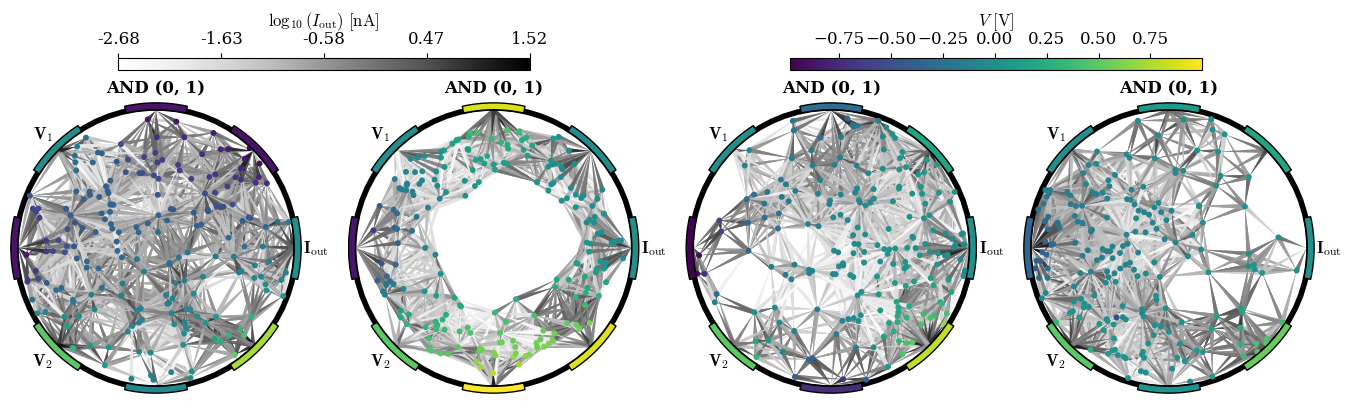

In [7]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

data_types = ['uni_1e7', 'data_vMB_ring_1e7', 'grad_towards_1e7', 'grad_away_1e7']
gate = 'AND'

volt_1 = .0
volt_2 = .5

label_map = {0: r'$\mathbf{I_{\mathrm{out}}}$', 3: r'$\mathbf{V_1}$', 5: r'$\mathbf{V_2}$'}

device_datas = []
for data in data_types:
    loaded_data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/'
    f'{data}_gate_data_alpha=1.0/{data}_gate={gate}_{volt_1}_{volt_2}_new_1.npz')
    device_datas.append(loaded_data)
print(len(device_datas))
plt.close('all')
fig = plot_many_devices(
    device_datas, 
    ncols=4, 
    energy_cmap='viridis', 
    electrode_label_map=label_map, 
    electrode_label_kwargs=dict(fontsize=12, fontweight='bold'),
    electrode_label_r=9.3
)
axs = fig.get_axes()

for i in range(len(device_datas)):
    axs[i].set_title(rf'{gate} ({int(volt_1 > 0.0)}, {int(volt_2 > 0.0)})', fontdict={'weight': 'bold'})
plt.savefig(f'{gate}_{int(volt_1 > 0.0)}_{int(volt_2 > 0.0)}.png', bbox_inches='tight', pad_inches=0.02)
plt.show();

4
all_pos_min: 0.00014388303405077506
all_pos_max: 32.89041784117582
vmin: 0.00014388303405077506
vmax: 32.89041784117582
lg_10 vmin: -3.8419904128217186
lg_10 vmax: 1.5170693908120645
min_net_events = 0
max_net_events = 144300
sim_time_ps = [865108.4325008]
Imax (nA) = [26.72429016]
I min nA: 0.0
I max nA: 26.724290161023855
log10(I max): 1.426906178492807
vmin_lin,vmax_lin: 0.00018519951601541138 26.724290161023855
curr_norm vmin/vmax: -3.8419904128217186 1.5170693908120645
min_net_events = 0
max_net_events = 139132
sim_time_ps = [1113527.13721244]
Imax (nA) = [20.01873429]
I min nA: 0.0
I max nA: 20.018734293552438
log10(I max): 1.3014366152660333
vmin_lin,vmax_lin: 0.00014388303405077506 20.018734293552438
curr_norm vmin/vmax: -3.8419904128217186 1.5170693908120645
min_net_events = 0
max_net_events = 136399
sim_time_ps = [664434.52074903]
Imax (nA) = [32.89041784]
I min nA: 0.0
I max nA: 32.89041784117582
log10(I max): 1.5170693908120645
vmin_lin,vmax_lin: 0.0002411338634533671 32.

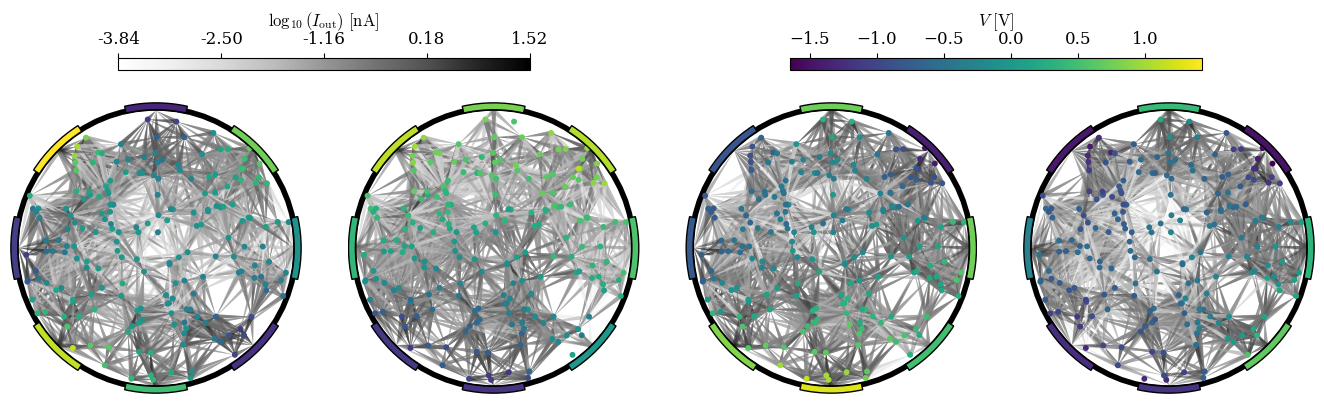

In [17]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

device_datas = []
for i in range(4):
    loaded_data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/'
    f'random_device_thesis_{i}.npz')
    device_datas.append(loaded_data)
print(len(device_datas))
plt.close('all')
fig = plot_many_devices(
    device_datas, 
    ncols=4, 
    energy_cmap='viridis', 
    electrode_label_map=None, 
    electrode_label_kwargs=None,
    electrode_label_r=None
)
axs = fig.get_axes()

#for i in range(len(device_datas)):
#    axs[i].set_title(rf'Random', fontdict={'weight': 'bold'})
plt.savefig(f'current_distributions_random_devices.png', bbox_inches='tight', pad_inches=0.02)
plt.show();